# Introduction to Exponential Smoothing
--------------------

A simple exponential smoothing is one of the simplest ways to forecast a time series. The basic idea of this model is to assume that the future will be more or less the same as the recent past. The only pattern that this model will be able to learn from demand history is its level.

The **level** is the average value around which the demand varies over time. As you can observe, the level is a smoothed version of the demand.

The exponential smoothing model will then forecast the future demand as its last estimation of the level. It is important to understand that there is no definitive mathematical definition of the level, instead **it is up to our model to estimate it**.

The exponential smoothing model will have some advantages compared to a naive or a moving average model.
* The weight that is put on each observation decreases **exponentially** over time
  * The most recent observation has the highest weight.
    * This is often better than the MA model where all observations are given equal weight.
* Outliers and noise have less impact than with the naive method.

# 🔴 Model

The underyling idea of any exponential smoothing is that, at each period, the model will learn a bit from the most recent demand observation and remember a little bit of the last forecast it did. The magic about this is that the last forecast the model did was including a part of the previous demand observation and a part of the previous forecast. And so forth.

* That means that this previous forecast actually includes everything the model learned so far based on demand history!

The smoothing parameter (or learning rate) **alpha** ($\alpha$) will determine how much importance is given to the most recent demand observation. Let's represent this mathematically.

<center>
$f_t = \alpha d_{t-1} + (1 - \alpha) f_{t-1}$

$0 \lt \alpha \leq 1 $

**What's the intuition behind this formula?**


*   $\alpha$ is a ratio (or a percentage) of how much importance the model will allocate to the most recent observation compared to the importance of demand history
*   $\alpha d_{t-1} $ represents the previous demand observation times the learning rate. You could say the model attaches a certain importance (alpha) to the latest demand occurence.
* $(1 + \alpha) f_{t-1}$ represents how much the model remembers from its previous forecast. Note that this is where the recursive magic happens as $f_{t-1}$ was itself defined as partially $d_{t-2}$ and $f_{t-2}$



There is an important trade-off to be made here between **learning** and **remembering**: between being reactive and being stable.
* If alpha is high, the model will allocate more importance to the recent demand observation (i.e. the model will learn fast) and it will be reactive to a change in the demand level
  * But it will also be sensitive to outliers and noise.
* On the other hand, if alpha is low, the model won't notice a change in level rapidly...
  * But will also not react to noise and outliers.

## 🔵 Model initialization

There are two ways we can initialize the model.
1. **Simple initialization:** We initialize the first forecast (period 0) as the first demand observation. Then we have

<center>
$f_0 = d_0$
</center>

This is a simple and fair way to initialize the forecast.

2. **Average:** We initialize the forecast as the average of the first $n$ demand occurences.

<center>
$f_0 = \frac{1}{n} \sum \limits_{t=0}^{n} d_t$
</center>

In such a case, I would test different values of $n$. It could either be fixed as a small value (3 to 5) or as the inverse of the learning rate (1/$\alpha$). If $n$ is set as the inverse of the learning rate, this allows a smoother estimation of $f_0$ as the learning rate decreases. This makes sense as a low value for $\alpha$ means that we want our model to react smoothly to variations.

## 🔵 Data leakage!
Be careful - it's easy to get a model by leaking information about the future... but you will possibly poison your model! Be fair with which information you train your model on.

# 🔴 Insights
## Impact of $\alpha$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
d = [1,2,3]
extra_periods=1
np.append(d, [np.nan]*extra_periods)


array([ 1.,  2.,  3., nan])

In [4]:
def simple_exp_smooth(d, extra_periods=1, alpha=0.4):

  # Transform the input into a numpy array
  d = np.array(d)
  # Historical period length
  cols = len(d)
  # Append np.nan into the demand array to cover future periods
  d = np.append(d, [np.nan]*extra_periods)

  # Forecast array
  f = np.full(cols + extra_periods, np.nan)
  # initialization of first forecast
  f[1] = d[0]

  # Create all the t+1 forecasts until end of historical period
  for t in range(2,cols+1):
    f[t] = alpha*d[t-1] + (1-alpha)*f[t-1]
  # Forecast for all extra periods
  f[cols+1:] = f[t]

  df = pd.DataFrame.from_dict({'Demand':d, 'Forecast':f, 'Error':d-f})
  return df

## 🔵 Playing with our function

### 🦾 Which value of alpha is best for this model?!
You can *hack* the values 0.1, 0.2...1 everything in between, or you can write a for loop!

shape of raw data: (21,)


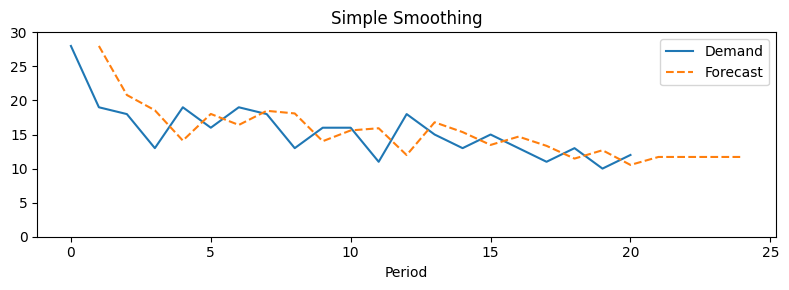

In [16]:
d=[28,19,18,13,19,16,19,18,13,16,16,11,18,15,13,15,13,11,13,10,12]
print('shape of raw data:', np.shape(d))
df = simple_exp_smooth(d, extra_periods=4, alpha=0.8)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Simple Smoothing',ylim=(0,30),style=['-','--'])
plt.tight_layout()

Try it in the Excel example too:
* https://docs.google.com/spreadsheets/d/1j4q4cYDy74x_HXk-2SnIDpBWE1To_DJARyDzs8enbY0/edit?usp=sharing

In [14]:
# look at the output
df.head()

,Demand,Forecast,Error
Period,,,
0,28.0,NaN,NaN
1,19.0,28.000,-9.000
2,18.0,20.800,-2.800
3,13.0,18.560,-5.560
4,19.0,14.112,4.888


In [18]:
df.tail(n=5)

,Demand,Forecast,Error
Period,,,
20,12.0,10.538711,1.461289
21,NaN,11.707742,NaN
22,NaN,11.707742,NaN
23,NaN,11.707742,NaN
24,NaN,11.707742,NaN


In [19]:
df.shape

(25, 3)

## 🔵 Metrics

In [ ]:
# error = actual - predicted
# when our model overestimates, you get a negative error.
# when our model underestimates, you get a positive error

In [21]:
MAE = df['Error'].abs().mean()
print("MAE:", round(MAE,2)) #
RMSE = np.sqrt((df['Error']**2).mean())
print('RMSE:', round(RMSE,2))


MAE: 3.06
RMSE: 3.72


### 🦾 On your own: add a scatterplot!
Of actual vs. predicted values

In [22]:
tmp = df
tmp.dropna(inplace=True)
tmp.head()

,Demand,Forecast,Error
Period,,,
1,19.0,28.0000,-9.0000
2,18.0,20.8000,-2.8000
3,13.0,18.5600,-5.5600
4,19.0,14.1120,4.8880
5,16.0,18.0224,-2.0224


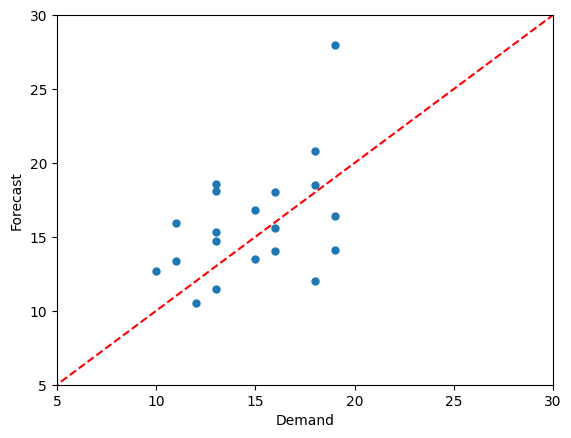

In [37]:
tmp.plot.scatter(x='Demand', y='Forecast', marker='.', s=100)
# Add a 45 degree line
plt.plot([0, 30], [0, 30], color='red', linestyle='--')
plt.xlim([5,30])
plt.ylim([5,30])
plt.show()

### 🦾 On your own: add a histogram of residuals
... and analyze if the residuals are centered around a value or are they skewed?

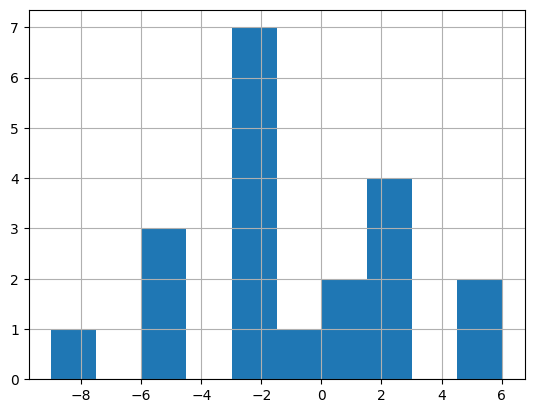

In [39]:
tmp['Error'].hist()
plt.show()

### 🦾 On your own: add a line plot!
Of residual vs. time... does your model get beter or worst over time, or does it look random?

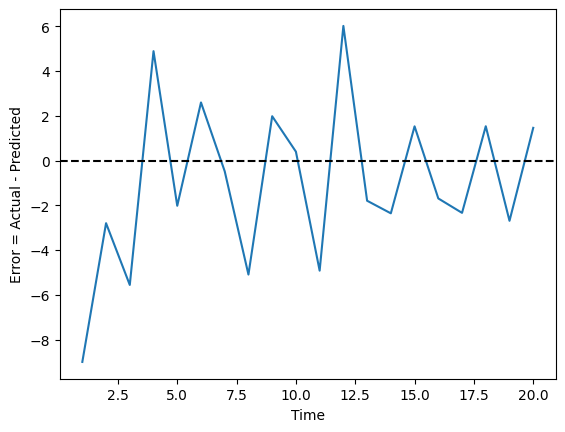

In [50]:
# plot error as a function of time
tmp['Error'].plot()
plt.ylabel('Error = Actual - Predicted')
plt.xlabel('Time')
# Add a horizontal line at y = 0
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

### 🦾 Clean up that x axis!

### 🦾 On your own: try to make a line plot of alpha vs. MAE (or RMSE)
Do you see a trend? Do you see a local minima where alpha optimizes the MAE (or RMSE)... it should go to zero if it is the best option.

### 🦾On your own: try to read some data from a .csv file...
... and get the same results! Maybe some oil price data or stock price data or weather data...

## 🔵 Comparing $\alpha$
A forecast made with a low alpha (0.1) will take more time to react to a changing demand, whereas a forecast with a high alpha value (0.8) will more closely follow the demand fluctuations.

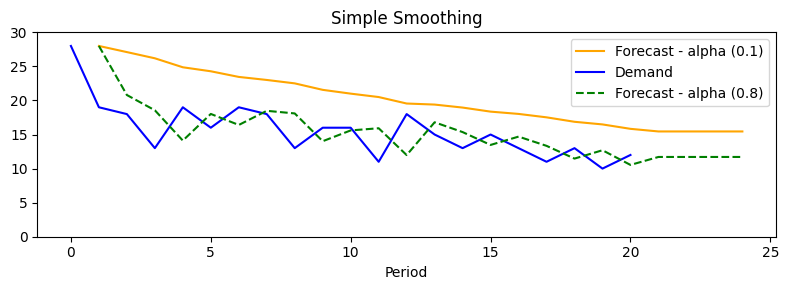

In [51]:
d=[28,19,18,13,19,16,19,18,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = simple_exp_smooth(d, extra_periods=4, alpha=0.1)
df.index.name = 'Period'
ax = df[['Forecast']].plot(figsize=(8,3),
                                    title='Simple Smoothing',
                                    ylim=(0,30),
                                    style=['-','--'],
                           color='orange')

df = simple_exp_smooth(d, extra_periods=4, alpha=0.8)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Simple Smoothing',
                               ylim=(0,30),style=['-','--'],
                               color=['blue', 'green'],
                               ax=ax)
plt.legend(['Forecast - alpha (0.1)',
           'Demand',
           'Forecast - alpha (0.8)'])
plt.tight_layout()

# 🔴 Why is it called exponential smoothing?

This model is called exponential smoothing as the weights given to each demand observation is exponentially reduced. To show this, we will start by taking us back to the exponential smoothing model.

<center>
$f_t = \alpha d_{t-1} + (1 - \alpha) f_{t-1}$
</center>

As you can see, the weight given to the most recent demand observation $d_{t-1}$ is $\alpha$. Now let's replace $f_{t-1}$ by its formula.

<center>
$f_{t} = \alpha d_{t-1} + (1 - \alpha) f_{t-1}$

...can be rewritten as...

$ f_{t} = \alpha d_{t-1} + (1 - \alpha) (\alpha d_{t-2} + (1 - \alpha) f_{t-2})$
</center>

If we do a bit of algebra, we obtain the following formula:

<center>
$ f_{t} = \alpha d_{t-1} + \alpha(1 - \alpha)d_{t-2} + (1 - \alpha)^{2} f_{t-2}$
</center>

We see that the weight given to the second most recent demand observation $d_{t-2}$ is $\alpha(1-\alpha)$, which is lower than the weight given to $d_{t-1}$.

Let's go further and replace $f_{t-2}$ by its formula.

<center>
$ f_{t} = \alpha d_{t-1} + \alpha(1 - \alpha)d_{t-2} + (1 - \alpha)^{2} (\alpha d_{t-3} + (1 - \alpha)f_{t-3})$
</center>

... which can be rewritten as...

<center>
$ f_{t} = \alpha d_{t-1} + \alpha(1 - \alpha)d_{t-2} + \alpha(1 - \alpha)^{2} d_{t-3} + (1 - \alpha)^{3} f_{t-3}$
</center>

We see that the weight given to $d_{t-3}$ is $\alpha(1-\alpha)^{2}$; which is the weight to $d_{t-2}$ multiplied by $(1-\alpha)$. From here, we deduce that the weight given to each further demand observation is reduced by a factor of $(1-\alpha)$. This is why we call this method **exponential smoothing**!

**Moving Average Model:** comparison of $n$ (these are the columns) and weighting observations (these are the values in the cells)

Period| 5 | 4| 3| 2| 1|
---|---|---|---|---|---|
$t-1$|0.2 | 0.25|0.33|0.5|1
$t-2$|0.2 | 0.25|0.33|0.5|
$t-3$|0.2 | 0.25|0.33||
$t-4$|0.2 | 0.25|||
$t-5$|0.2 | |||

**Exponential Smoothing Model:** comparison of $\alpha$ (these are the columns) and weighting observations (these are the values in the cells)

Period| 0.2 | 0.4 | 0.6| 0.8| 1|
---|---|---|---|---|---|
$t-1$|0.20 | 0.40|0.60|0.80|1
$t-2$|0.16 | 0.24|0.24|0.16|
$t-3$|0.13 | 0.14|0.10|0.03|
$t-4$|0.10 | 0.09|0.04|0.01|
$t-5$|0.08 | 0.05|0.02||

Look at how the weights allocated to each historical period can vary! Which one makes most sense to you? Which one is right for your business problem?

## 🔵 Limitations

The simple exponential smoothing model is slightly smarter than the moving average model thanks to its smarter weighting of the historical demand observation. But it has many limitations:
* It does not predict trends. We can solve this with another model - the exponential smoothing with a trend (otherwise known as **double exponential smoothing**)
* It does not recognize any seasonal pattern. You can solve this with the **triple exponential smoothing** model.
* It cannot use any external information (such as pricing or marketing expenses.)

In conclusion, this first exponential smoothing model will be most likely too simple to achieve good results, but it's a good foundation block.